# Skill Nexis Internship - Week 1

## Mini Project 1: Titanic Survival Prediction - Data Cleaning Project

In [125]:
import pandas as pd

In [126]:
df = pd.read_csv("train.csv")

In [127]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [128]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [129]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [130]:
df["Age"].median()

28.0

In [131]:
df["Age"] = df["Age"].fillna(df["Age"].median())

In [132]:
df["Age"].isnull().sum()

np.int64(0)

In [133]:
df["Embarked"].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [134]:
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [135]:
df["Embarked"].isnull().sum()

np.int64(0)

In [136]:
df["Cabin"] = df["Cabin"].fillna("Unknown")

In [137]:
df["Cabin"].isnull().sum()

np.int64(0)

In [138]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

In [139]:
from sklearn.preprocessing import LabelEncoder

In [140]:
le = LabelEncoder()
df["Sex"] = le.fit_transform(df["Sex"])

In [141]:
df[["Sex"]].head()

,Sex
0,1
1,0
2,0
3,0
4,1


In [142]:
le.classes_

array(['female', 'male'], dtype=object)

In [143]:
from sklearn.preprocessing import OneHotEncoder

In [144]:
encoder = OneHotEncoder(sparse_output=False)

In [145]:
embarked_encoded = encoder.fit_transform(df[["Embarked"]])

In [146]:
encoder.get_feature_names_out(["Embarked"])

array(['Embarked_C', 'Embarked_Q', 'Embarked_S'], dtype=object)

In [147]:
encoded_df = pd.DataFrame(
    embarked_encoded,
    columns=encoder.get_feature_names_out(["Embarked"]),
    index=df.index
)

In [148]:
df = pd.concat([df, encoded_df], axis=1)

In [149]:
df[["Embarked", "Embarked_C", "Embarked_Q", "Embarked_S"]].head()

,Embarked,Embarked_C,Embarked_Q,Embarked_S
0,S,0.0,0.0,1.0
1,C,1.0,0.0,0.0
2,S,0.0,0.0,1.0
3,S,0.0,0.0,1.0
4,S,0.0,0.0,1.0


In [150]:
df = df.drop("Embarked", axis=1)

In [151]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,Unknown,0.0,0.0,1.0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C85,1.0,0.0,0.0
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,Unknown,0.0,0.0,1.0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,C123,0.0,0.0,1.0
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,Unknown,0.0,0.0,1.0


In [152]:
df[["Embarked_C", "Embarked_Q", "Embarked_S"]].isnull().sum()

Embarked_C    0
Embarked_Q    0
Embarked_S    0
dtype: int64

In [153]:
import matplotlib.pyplot as plt

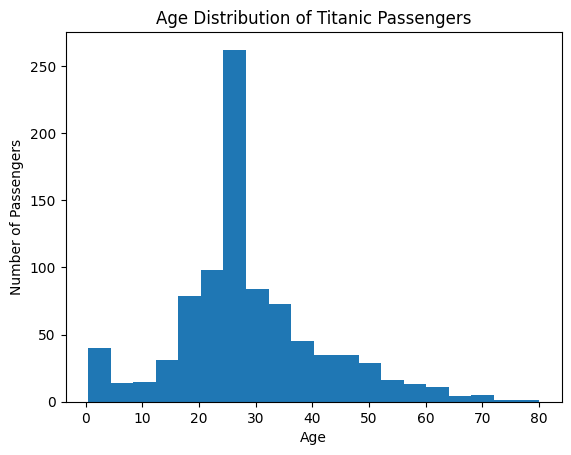

In [154]:
plt.hist(df["Age"], bins=20)
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.title("Age Distribution of Titanic Passengers")
plt.show()

In [155]:
df.to_csv("cleaned_titanic.csv", index=False)

## Conclusion

The Titanic dataset was cleaned by handling missing values in Age, Cabin, and Embarked. 
The Sex and Embarked columns were encoded into numerical values, the age distribution 
was visualized, and the cleaned dataset was saved as cleaned_titanic.csv.